#### ref: https://www.tensorflow.org/tutorials/

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import os

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

### load data

In [ ]:
import kagglehub

# Download dataset and get path
data_dir = kagglehub.dataset_download("arunrk7/surface-crack-detection")

print("Path to dataset files:", data_dir)

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
Path to dataset files: /kaggle/input/surface-crack-detection


In [ ]:
batch_size = 16
img_height = 128
img_width = 128


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  directory = data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 40000 files belonging to 2 classes.
Using 32000 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  directory = data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Negative', 'Positive']


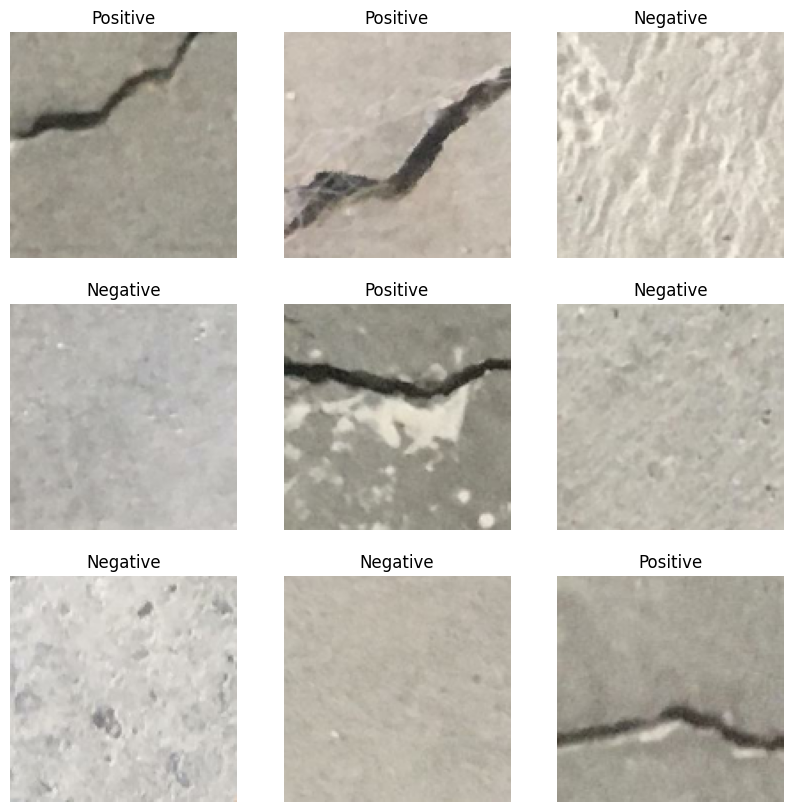

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(16, 128, 128, 3)
(16,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# Removed .cache() — it loads entire dataset into RAM (causes OOM on 12GB)
# Reduced shuffle buffer from 1000 to 200 to save memory
train_ds = train_ds.shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.33777517 0.9258839


## Basic Model 1

In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,122 (8.09 MB)

 Trainable params: 2,121,122 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10  # reduced from 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 116s 55ms/step - accuracy: 0.9662 - loss: 0.1007 - val_accuracy: 0.9912 - val_loss: 0.0267
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9889 - loss: 0.0362 - val_accuracy: 0.9911 - val_loss: 0.0259
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9924 - val_loss: 0.0228
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9923 - val_loss: 0.0205
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9953 - loss: 0.0162 - val_accuracy: 0.9933 - val_loss: 0.0206
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.9965 - val_loss: 0.0112
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9942 - val_loss: 0.0218
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.9967 

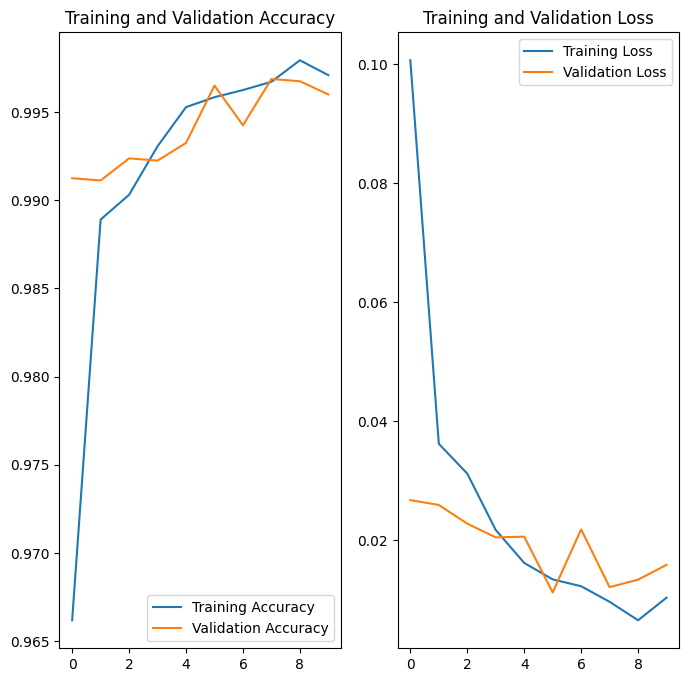

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### data augmentation

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

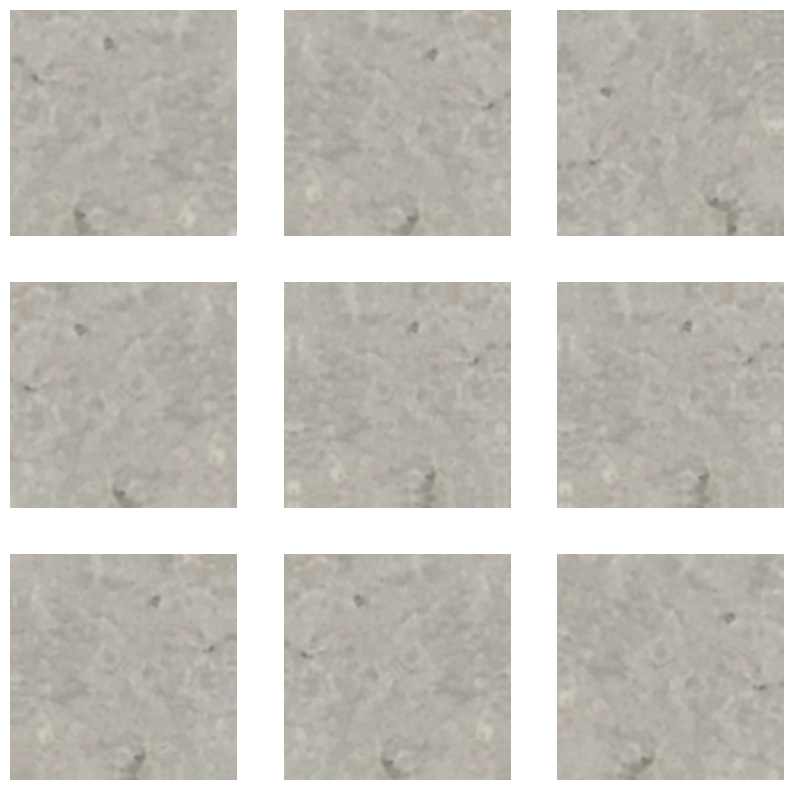

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

## Model 2

In [ ]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,122 (8.09 MB)

 Trainable params: 2,121,122 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 5
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9607 - loss: 0.1185 - val_accuracy: 0.9860 - val_loss: 0.0468
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9834 - loss: 0.0564 - val_accuracy: 0.9879 - val_loss: 0.0399
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9902 - loss: 0.0361 - val_accuracy: 0.9924 - val_loss: 0.0230
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9898 - loss: 0.0377 - val_accuracy: 0.9896 - val_loss: 0.0328
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9917 - loss: 0.0275 - val_accuracy: 0.9893 - val_loss: 0.0467


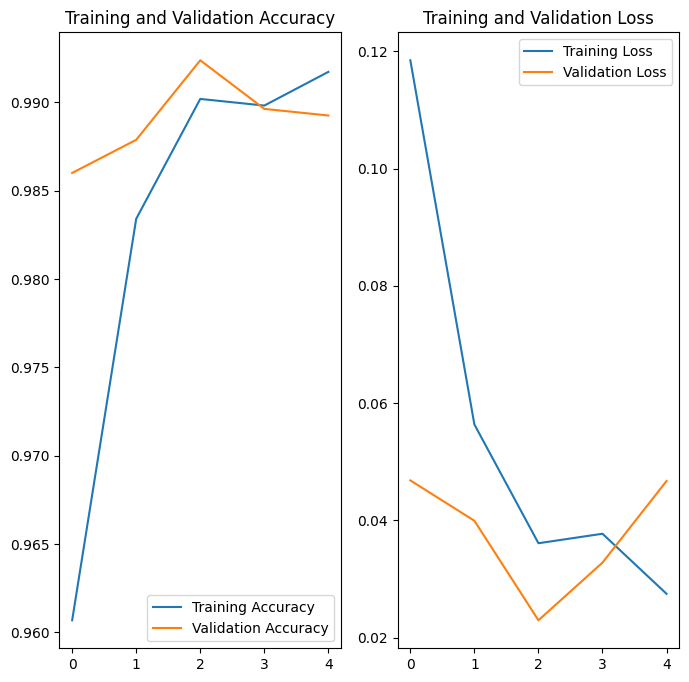

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.save("crack_detector_model.keras")

In [ ]:
pip install streamlit tensorflow pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.1 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

# Set page configuration
st.set_page_config(page_title="3D Print Crack Detector", layout="centered")

st.title("🔍 3D Printer Defect Detection")
st.write("Upload a photo of a 3D print to check for surface cracks.")

# 1. Load the trained model
# Ensure 'crack_detector_model.keras' is in the same directory as this script
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("crack_detector_model.keras")

try:
    model = load_model()
    class_names = ['Negative', 'Positive'] # Based on your notebook
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# 2. Image Uploading
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_container_width=True)

    st.write("---")

    # 3. Preprocessing (Matching notebook specs: 128x128)
    img_height, img_width = 128, 128

    # Convert image to RGB if it isn't already
    if image.mode != "RGB":
        image = image.convert("RGB")

    img_resized = image.resize((img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img_resized)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    # 4. Prediction
    if st.button('Predict'):
        with st.spinner('Analyzing surface...'):
            predictions = model.predict(img_array)
            score = tf.nn.softmax(predictions[0])

            result = class_names[np.argmax(score)]
            confidence = 100 * np.max(score)

            # 5. Display Results
            if result == "Positive":
                st.error(f"Crack Detected! (Confidence: {confidence:.2f}%)")
            else:
                st.success(f"No Crack Detected (Confidence: {confidence:.2f}%)")

2026-04-21 08:59:40.398 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:59:40.399 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:59:40.958 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-21 08:59:40.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:59:40.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:59:40.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 08:59:40.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
!pip install -q streamlit pyngrok tensorflow pillow

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

st.title("🔍 3D Printer Crack Detector")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("crack_detector_model.keras")

model = load_model()
class_names = ['Negative', 'Positive']

uploaded_file = st.file_uploader("Upload a photo", type=["jpg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption='Uploaded Image', use_container_width=True)

    img_resized = image.resize((128, 128))
    img_array = tf.keras.utils.img_to_array(img_resized)
    img_array = tf.expand_dims(img_array, 0)

    if st.button('Predict'):
        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0])
        result = class_names[np.argmax(score)]
        st.write(f"Result: **{result}** ({100 * np.max(score):.2f}%)")

Writing app.py


In [ ]:
import urllib
print("Password/Endpoint IP:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Password/Endpoint IP: 34.16.160.65


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# Kill any previous streamlit instances
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(1)

# Start Streamlit in background
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])
time.sleep(3)

# Connect ngrok
ngrok.set_auth_token("3CcHOkxxlrxEasdQGWhzEqtJ8jD_75jiXdU7JyGuCmXVGwCWi")  # <-- paste your token
public_url = ngrok.connect(8501)
print("✅ Open your dashboard at:", public_url)